| Task                                                                              | Status      | Results                                    | Individual Responsible (Kauthara) |
|-----------------------------------------------------------------------------------|-------------|-----------------------------------------------------|-----------------------------------|
| Non-causal transformer w/ pretrained skip-gram (Godin Twitter vectors, 400d)      | Completed   | Used frozen embedding, max_len=51, 4 heads         |                                   |
| Position embeddings added                                                          | Completed   | Yes                                                |                                   |
| Max pooling layer                                                                  | Completed   | Yes                                                |                                   |
| Dropout in attention                                                               | Completed   | Yes (0.3)                                          |                                   |
| Model trainable param (embedding) set to False                                     | Completed   | Yes                                                |                                   |
| Model training time                                                                | Completed   | 83.04 minutes                                      |                                   |
| Train set accuracy                                                      | Completed   | Acc=0.8403                                       |                                   |
| Test set accuracy                                                 | Completed   | Acc=0.7657                                         |                                   |
| Train set F1-score: Positive                                                       | Completed   | 0.87                                               |                                   |
| Train set F1-score: Neutral                                                        | Completed   | 0.81                                               |                                   |
| Train set F1-score: Negative                                                       | Completed   | 0.85                                               |                                   |
| Test set F1-score: Positive                                                        | Completed   | 0.81                                              |                                   |
| Test set F1-score: Neutral                                                         | Completed   | 0.71                                               |                                   |
| Test set F1-score: Negative                                                        | Completed   | 0.78                                               |                                   |
| Train set ROC-AUC (OvR, per class)                                                 | Completed   | 0.953                                          |                                   |
| Test set ROC-AUC (OvR, per class)                                                  | Completed   | 0.9113                                              |                                   |
| Confusion matrix (Train)                                                           | Completed   | Built                                    |                                   |
| Confusion matrix (Test)                                                            | Completed   | Built                                   |                                   |
| Most important words (LIME, local explainability)                                  | Completed   | Yes (see LIME output)                              |                                   |


In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import string
import emoji
import unicodedata
import nltk
import spacy
from spacy import displacy
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Emoji handling
import emoji

# Spell correction and contractions
from textblob import TextBlob
import contractions
from langdetect import detect, LangDetectException

# Multiprocessing and progress bars
from multiprocessing import Pool, cpu_count
from functools import lru_cache, partial
from tqdm import tqdm

# ML and encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Deep learning tools
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model, Input

# Word embeddings
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize


In [2]:
# Setup NLP resources
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
spacy_nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()

In [3]:
# Load spaCy model for NER
import en_core_web_sm
nlp_spacy = en_core_web_sm.load()

# Disable unnecessary components for faster NER
nlp_spacy.disable_pipes("tagger", "parser", "lemmatizer")

['tagger', 'parser', 'lemmatizer']

In [4]:
# Load Data
corpus_df = pd.read_csv("Sentiment_Data.csv", encoding="ISO-8859-1")

In [5]:
# Check the head of the dataframe
corpus_df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [6]:
# Show data overview
print("Dataset Overview:")
print(f"Dataset shape: {corpus_df.shape}")
print(f"Columns: {corpus_df.columns.tolist()}")
print("\nSentiment Distribution:")
print(corpus_df['Sentiment'].value_counts())

Dataset Overview:
Dataset shape: (451332, 2)
Columns: ['Tweet', 'Sentiment']

Sentiment Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [7]:
# Create abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "n": "and",
    "2": "to",
    "4": "for",
    "w/": "with",
    "w/o": "without",
    "thru": "through",
    "tho": "though",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "outta": "out of",
    "dunno": "don't know",
    "gimme": "give me",
    "lemme": "let me",
    "btw": "by the way",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "rofl": "rolling on floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "aka": "also known as",
    "asap": "as soon as possible",
    "fyi": "for your information",
    "diy": "do it yourself",
    "faq": "frequently asked questions",
    "irl": "in real life",
    "ppl": "people",
    "msg": "message",
    "txt": "text",
    "pic": "picture",
    "vid": "video",
    "app": "application",
    "tech": "technology",
    "biz": "business",
    "edu": "education",
    "gov": "government",
    "org": "organization",
    "info": "information",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "afaik": "as far as i know",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "fwiw": "for what it is worth",
    "ftw": "for the win",
    "lmk": "let me know",
    "rn": "right now",
    "thx": "thanks",
    "til": "today i learned",
    "brb": "be right back",
    "gg": "good game",
    "noob": "newbie",
    "ootd": "outfit of the day",
    "fyp": "for you page",
    "hmu": "hit me up",
    "iiuc": "if i understand correctly",
    "ikr": "i know, right",
    "irl": "in real life",
    "iss": "i am so sorry",
    "jsyk": "just so you know",
    "lowkey": "quietly",
    "highkey": "obviously",
    "ngl": "not gonna lie",
    "oot": "out of the",
    "pls": "please",
    "rizz": "charisma",
    "ship": "support a romantic relationship",
    "slay": "do something well",
    "s/o": "shoutout",
    "stan": "support",
    "tbf": "to be fair",
    "tea": "gossip",
    "vibe check": "evaluation of mood",
    "wtf": "what the freak",
    "wym": "what you mean",
    "yaaas": "strong agreement",
    "cc": "carbon-copy",
    "cx": "correction",
    "ct": "cut tweet",
    "dm": "direct message",
    "ht": "hat tip",
    "mt": "modified tweet",
    "prt": "please retweet",
    "rt": "retweet",
    "em": "email marketing",
    "ezine": "electronic magazine",
    "fb": "facebook",
    "li": "linkedin",
    "seo": "search engine optimization",
    "sm": "social media",
    "smm": "social media marketing",
    "smo": "social media optimization",
    "sn": "social network",
    "sroi": "social return on investment",
    "ugc": "user generated content",
    "yt": "youtube",
    "ab/abt": "about",
    "b4": "before",
    "bfn": "bye for now",
    "bgd": "background",
    "bh": "blockhead",
    "br": "best regards",
    "cd9": "code 9",
    "chk": "check",
    "cul8r": "see you later",
    "dam": "don not annoy me",
    "dd": "dear daughter",
    "df": "dear fiancé",
    "dp": "profile pic",
    "ds": "dear son",
    "dyk": "did you know, do you know",
    "ema": "email address",
    "ftf": "face to face",
    "f2f": "face to face",
    "ff": "follow friday",
    "fotd": "find of the day",
    "gts": "guess the song",
    "hagn": "have a good night",
    "hand": "have a nice day",
    "hotd": "headline of the day",
    "hth": "hope that helps",
    "ic": "i see",
    "iirc": "if i remember correctly",
    "jk": "just kidding, joke",
    "jv": "joint venture",
    "kk": "ok got it",
    "kyso": "knock your socks off",
    "lhh": "laugh hella hard",
    "lmao": "laughing my ass off",
    "lo": "little one",
    "mm": "music monday",
    "mirl": "meet in real life",
    "nbd": "no big deal",
    "nct": "nobody cares, though",
    "nfw": "no freaking way",
    "njoy": "enjoy",
    "nsfw": "not safe for work",
    "nts": "note to self",
    "oh": "overheard",
    "omfg": "oh my freaking god",
    "oomf": "one of my followers",
    "orly": "oh really",
    "plmk": "please let me know",
    "pnp": "party and play",
    "qotd": "quote of the day",
    "re": "in reply to, in regards to",
    "rlrt": "real-life re-tweet",
    "rtq": "read the question",
    "sfw": "safe for work",
    "smdh": "shaking my damn head",
    "so": "significant other",
    "srs": "serious",
    "tftf": "thanks for the follow",
    "tf": "thanks for this tweet",
    "tj": "tweetjack",
    "tl": "timeline",
    "tldr": "too long, did not read",
    "tmb": "tweet me back",
    "tt": "trending topic",
    "tyia": "thank you in advance",
    "tyt": "take your time",
    "tyvw": "thank you very much",
    "w/": "with",
    "w/e": "weekend",
    "wtv": "whatever",
    "ygtr": "you got that right",
    "ykwim": "you know what i mean",
    "ykyat": "you know you are addicted to",
    "ymmv": "your mileage may vary",
    "yolo": "you only live once",
    "yoyo": "you are on your own",
    "yw": "you are welcome",
    "zomg": "omg to the max"
}
lemmatizer = WordNetLemmatizer()

### Text Cleaning Functions

In [8]:
# Function to clean dataset
def process_emojis_symbols(text):
    if not isinstance(text, str):
        return ""
    # Process emojis
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove non-grammatical symbols
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'@\w+', ' ', text)                   # Mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # hashtags keep text
    text = re.sub(r'[^a-zA-Z0-9\s\-]', ' ', text)       # non-alphanum except hyphens

    # Expand contractions
    text = contractions.fix(text)

    return text

# Named Entity Recognition Processing
def extract_entities(text):
    return " ".join([ent.text for ent in nlp_spacy(text).ents]) or text

# Spelling corrections
def correct_spelling(text):
    return str(TextBlob(text).correct()) if isinstance(text, str) else ""

# Slang and Abbreviation handler
def expand_slangs(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

# Non-grammatical punctuation removal
def remove_punctuations(text):
    text = re.sub(r'[^\w\s-]', ' ', text)  # Keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Helper to convert nltk POS tags to wordnet tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # Save memory

def lemmatize_texts_spacy(texts, batch_size=1000):
    for doc in nlp.pipe(texts, batch_size=batch_size):
        yield " ".join([
            token.text if token.text.startswith('#') or token.text.startswith('@') or token.text.isupper()
            else token.lemma_.lower()
            for token in doc if not (token.is_punct or token.is_space)
        ])

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False


### Complete Pipeline

In [9]:
def clean_pipeline(text):
    text = process_emojis_symbols(text)
    # text = extract_entities(text) Skipped due to excessive computational requirements
    text = text.lower()
    # text = correct_spelling(text) Skipped due to excessive computational requirements
    text = expand_slangs(text)
    text = remove_punctuations(text)
    return text

In [10]:
corpus_df['Tweet'] = corpus_df['Tweet'].fillna("")

In [11]:
# Processing the pipeline
tqdm.pandas()
corpus_df['Cleaned_Text'] = corpus_df['Tweet'].progress_apply(clean_pipeline)

100%|██████████| 451332/451332 [01:12<00:00, 6191.16it/s]


In [12]:
# Lemmatize in batch
corpus_df['Cleaned_Text'] = list(lemmatize_texts_spacy(corpus_df['Cleaned_Text']))

# Filter to English only
corpus_df = corpus_df[corpus_df['Cleaned_Text'].apply(is_english)].reset_index(drop=True)


In [13]:
# Check the new dataframe
corpus_df.head()

,Tweet,Sentiment,Cleaned_Text
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos,happy anniversary the day the freedumb die in ...
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos,happy anniversary the day the freedumb die in ...
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos,happy anniversary the day the freedumb die in ...
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...


In [14]:
corpus_df['Cleaned_Text'].tail(20)


429498    watch zuma and banda at freedom statue listen ...
429499    the red gossip party express bus be the ronald...
429500    gossip party express on the road again pull in...
429501    retweet direction and parking information for ...
429502    teaparty express be also know as wheel for fre...
429503    gossip party express wheel of freedom be take ...
429504    retweet teaparty express arrive in albuquerque...
429505    teaparty express just arrive in albuquerque to...
429506    security convoy on way to pick up convict lock...
429507    new blog post freedom convoy tour the okanagan...
429508    new blog post freedom convoy regional schedule...
429509    new blog post freedom route convoy will stop i...
429510    freedom convoy make city stop the army navy ai...
429511    next week freedom snatch go for 44- tie convoy...
429512    broll of a navy convoy cross the kuwaiti iraqi...
429513    watch broll of a navy convoy cross the kuwaiti...
429514    gaza peace and freedom viva pa

In [15]:
#Sanity Check to see if Lemmetization worked well

In [16]:
samples = corpus_df.sample(5)
for i, row in samples.iterrows():
    print("Original:", row["Tweet"])
    print("Cleaned:", clean_pipeline(row["Tweet"]))
    print("-" * 40)

Original: As Freedom Convoy Gets Stronger, Canada Broadens 'Terrorist Financing' Rules https://t.co/uygwFNMoJh https://t.co/iRPlY63e1O
Cleaned: as freedom convoy gets stronger canada broadens terrorist financing rules
----------------------------------------
Original: Canadian legal group sues Trudeau govât for using Emergencies Act against peaceful Freedom Convoy.
https://t.co/F4q6S6Gfic
Cleaned: canadian legal group sues trudeau govat for using emergencies act against peaceful freedom convoy
----------------------------------------
Original: @KarenKrumbholz @Livelifejoyful2 God Bless their battle!
&amp; Those in France &amp; New Zealand, &amp; the upcoming Freedom Convoy in the USA. ð
Cleaned: god bless their battle amp those in france amp new zealand amp the upcoming freedom convoy in the usa
----------------------------------------
Original: @faraimupfuti @_BarringtonII @shaunking @elonmusk But terrorists DO have a voice on Twitter rn. Twitter says they donât allow hacked ma

In [97]:
corpus_df.to_csv('corpus_df_full.csv', index=False)


### Check the Data Quality

In [18]:
# Data Quality Report
print("\n=== Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Missing values: {corpus_df['Cleaned_Text'].isnull().sum():,}")
print(f"Empty strings after cleaning: {corpus_df['Cleaned_Text'].eq('').sum():,}")


=== Data Quality Report ===
Total samples: 429,518
Missing values: 0
Empty strings after cleaning: 0


In [19]:
# Remove empty texts
corpus_df = corpus_df[corpus_df['Cleaned_Text'].str.strip().astype(bool)]

### Consolidate Sentiments

In [20]:
# Merge sentiment categories
def merge_sentiments(sentiment):
    if sentiment in ['Mild_Pos', 'Strong_Pos']:
        return 'Positive'
    elif sentiment in ['Mild_Neg', 'Strong_Neg']:
        return 'Negative'
    else:
        return 'Neutral'

corpus_df['Sentiment_Merged'] = corpus_df['Sentiment'].apply(merge_sentiments)
print("\nMerged Sentiment Distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())


Merged Sentiment Distribution:
Sentiment_Merged
Positive    285687
Negative     75117
Neutral      68714
Name: count, dtype: int64


In [21]:
# Balance dataset
sample_size = 30000
print(f"Balancing dataset with {sample_size} samples per class.")

def balance_dataset(df, target_col='Sentiment_Merged', min_count=None):
    if min_count is None:
        min_count = df[target_col].value_counts().min()

    balanced_dfs = []
    for sentiment in df[target_col].unique():
        sentiment_df = df[df[target_col] == sentiment]
        if len(sentiment_df) > min_count:
            balanced_df = sentiment_df.sample(n=min_count, random_state=42)
        else:
            balanced_df = sentiment_df
        balanced_dfs.append(balanced_df)

    return pd.concat(balanced_dfs, ignore_index=True)

balanced_corpus = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")

Balancing dataset with 30000 samples per class.
Balanced dataset shape: (90000, 4)


In [22]:
corpus_df = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")
print("Balanced sentiment distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())

Balanced dataset shape: (90000, 4)
Balanced sentiment distribution:
Sentiment_Merged
Positive    30000
Neutral     30000
Negative    30000
Name: count, dtype: int64


In [23]:
corpus_df["Tokenized_Tweet"] = corpus_df["Cleaned_Text"].apply(lambda x: word_tokenize(x))

In [24]:
corpus_df['token_count'] = corpus_df['Tokenized_Tweet'].apply(len)


## CHECKING TOKEN COUNT TO SET MAX_LENGTH

count    90000.000000
mean        23.976022
std         13.280130
min          1.000000
25%         13.000000
50%         22.000000
75%         36.000000
max        179.000000
Name: token_count, dtype: float64
Max: 179
99th percentile: 51.0


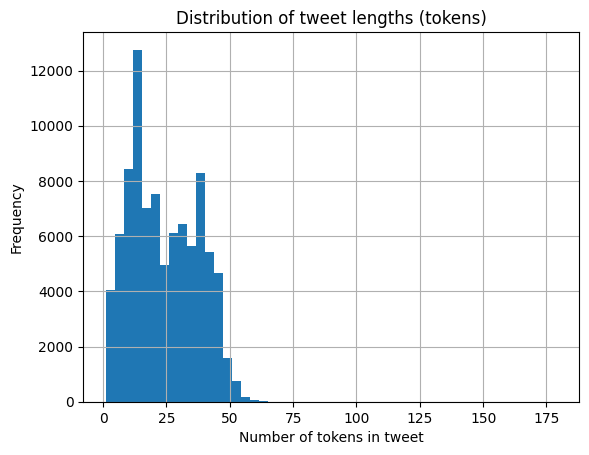

In [25]:
print(corpus_df['token_count'].describe())
print("Max:", corpus_df['token_count'].max())
print("99th percentile:", corpus_df['token_count'].quantile(0.99))

import matplotlib.pyplot as plt
corpus_df['token_count'].hist(bins=50)
plt.xlabel("Number of tokens in tweet")
plt.ylabel("Frequency")
plt.title("Distribution of tweet lengths (tokens)")
plt.show()

### Train-Test Splits for Models

In [58]:
# Split on the raw dataframe and label column
train_df, test_df = train_test_split(
    corpus_df, test_size=0.2, random_state=42, stratify=corpus_df['Sentiment_Merged']
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['Sentiment_Merged'])  
y_test  = label_encoder.transform(test_df['Sentiment_Merged'])      


# Tokenization and Sequence Prepping

In [61]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["Cleaned_Text"])        # Fit only on train!
X_train_seq = tokenizer.texts_to_sequences(train_df["Cleaned_Text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["Cleaned_Text"])

In [63]:
train_df.head()

,Tweet,Sentiment,Cleaned_Text,Sentiment_Merged,Tokenized_Tweet,token_count
11291,"@RyanSarai1 @OttawaCitizen I thought ""Miss Fre...",Mild_Pos,i think miss freedom convoy 2022 be break be t...,Positive,"[i, think, miss, freedom, convoy, 2022, be, br...",19
45866,@AndrewLawton Ahhhh dear Catharine. Look up vi...,Neutral,ahhhh dear catharine look up video of her do p...,Neutral,"[ahhhh, dear, catharine, look, up, video, of, ...",40
84016,Shared post - Canadian Fake Anti-Hate Network ...,Mild_Neg,share post canadian fake anti hate network lea...,Negative,"[share, post, canadian, fake, anti, hate, netw...",23
49940,@DDay_Cobra #FreedomConvoy,Neutral,freedomconvoy,Neutral,[freedomconvoy],1
87850,Canadian 'freedom' truckers massive vaccine ma...,Mild_Neg,canadian freedom truckers massive vaccine mand...,Negative,"[canadian, freedom, truckers, massive, vaccine...",13


In [64]:
max_len = 51
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")


### MODEL BUILDING

## About the Pretrained Model Used

For this project, we used the **Godin Twitter Word2Vec model** (commonly referred to as `word2vec_twitter_tokens`), which is a skip-gram word2vec embedding trained on approximately 400 million English-language tweets.

- **Type:** Skip-gram Word2Vec  
- **Vector size:** 400 dimensions  
- **Corpus:** 400M English tweets  

**Why chosen:**  
- Specifically designed for short, informal, and noisy Twitter text (matching our dataset).  
- Captures social media slang, abbreviations, hashtags, and real tweet context much better than news or Wikipedia embeddings.  
- Widely used in Twitter-related NLP tasks and research.


# Loading Pretrained Twitter Model of Word2vec using Skip-Gram

In [65]:
from gensim.models import KeyedVectors

w2v_path = 'word2vec_twitter_tokens.bin'
embedding_dim = 400

w2v_model = KeyedVectors.load_word2vec_format(w2v_path, binary=True, encoding="latin-1")

Checking the number of Vocabulary that can be found in the Embedded layer

In [66]:
vocab_size = 10000  
embedding_matrix = np.zeros((vocab_size, embedding_dim))
found = 0

for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
        found += 1

print(f"{found}/{vocab_size} words found in the pretrained embeddings ({100*found/vocab_size:.2f}%).")


8485/10000 words found in the pretrained embeddings (84.85%).


In [67]:
print("Max index in X_train:", np.max(X_train))
assert np.max(X_train) < vocab_size, "There are out-of-vocabulary indices!"

Max index in X_train: 9999


#  Build Non-Causal Transformer Model with Position Embedding 

In [68]:
class PositionEmbedding(layers.Layer):
    def __init__(self, max_len, embedding_dim):
        super().__init__()
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        pos_encoding = self.pos_emb(positions)
        return x + pos_encoding

def build_transformer_model(vocab_size, embedding_dim, max_len, n_classes):
    inputs = Input(shape=(max_len,), dtype="int32")
    # 1. Pretrained Word2Vec embedding, frozen
    embed = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False,           # <- frozen
        mask_zero=True
    )(inputs)
    # 2. Position embedding
    pos_embed = PositionEmbedding(max_len, embedding_dim)(embed)
    # 3. Non-causal Transformer Encoder
    x = layers.LayerNormalization(epsilon=1e-6)(pos_embed)
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=embedding_dim, dropout=0.3)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(embedding_dim, activation="relu")(x)
    # 4. Max pooling
    x = layers.GlobalMaxPooling1D()(x)
    # 5. Output head
    outputs = layers.Dense(3, activation="softmax")(x)
    return Model(inputs, outputs)

n_classes = 3
model = build_transformer_model(vocab_size, embedding_dim, max_len, n_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 51)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 51, 400)   │  4,000,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding… │ (None, 51, 400)   │     20,400 │ embedding_4[0][0] │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 51, 400)   │        800 │ position_embeddi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 51, 400)   │  2,565,200 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 51, 400)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 51, 400)   │        800 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 51, 400)   │    160,400 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 400)       │          0 │ dense_4[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │      1,203 │ global_max_pooli… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,748,803 (25.74 MB)

 Trainable params: 2,748,803 (10.49 MB)

 Non-trainable params: 4,000,000 (15.26 MB)

In [69]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
history = model.fit(
    X_train, y_train,              # use your padded input and encoded labels
    epochs=10,
    batch_size=64,
    validation_split=0.1,          # randomly uses 10% of X_train/y_train for val
    callbacks=[early_stop],
    verbose=2
)
train_time = time.time() - start_time
print(f"Training time: {train_time/60:.2f} minutes")


Epoch 1/10
1013/1013 - 1357s - 1s/step - accuracy: 0.6708 - loss: 0.7521 - val_accuracy: 0.7192 - val_loss: 0.6544
Epoch 2/10
1013/1013 - 387s - 382ms/step - accuracy: 0.7339 - loss: 0.6315 - val_accuracy: 0.7429 - val_loss: 0.6129
Epoch 3/10
1013/1013 - 382s - 377ms/step - accuracy: 0.7533 - loss: 0.5894 - val_accuracy: 0.7443 - val_loss: 0.6136
Epoch 4/10
1013/1013 - 411s - 405ms/step - accuracy: 0.7649 - loss: 0.5627 - val_accuracy: 0.7593 - val_loss: 0.5950
Epoch 5/10
1013/1013 - 431s - 425ms/step - accuracy: 0.7779 - loss: 0.5383 - val_accuracy: 0.7492 - val_loss: 0.5817
Epoch 6/10
1013/1013 - 408s - 403ms/step - accuracy: 0.7881 - loss: 0.5161 - val_accuracy: 0.7633 - val_loss: 0.5666
Epoch 7/10
1013/1013 - 407s - 402ms/step - accuracy: 0.7966 - loss: 0.4968 - val_accuracy: 0.7633 - val_loss: 0.5785
Epoch 8/10
1013/1013 - 395s - 390ms/step - accuracy: 0.8046 - loss: 0.4768 - val_accuracy: 0.7653 - val_loss: 0.5661
Epoch 9/10
1013/1013 - 403s - 398ms/step - accuracy: 0.8167 - loss

# Model Evaluation

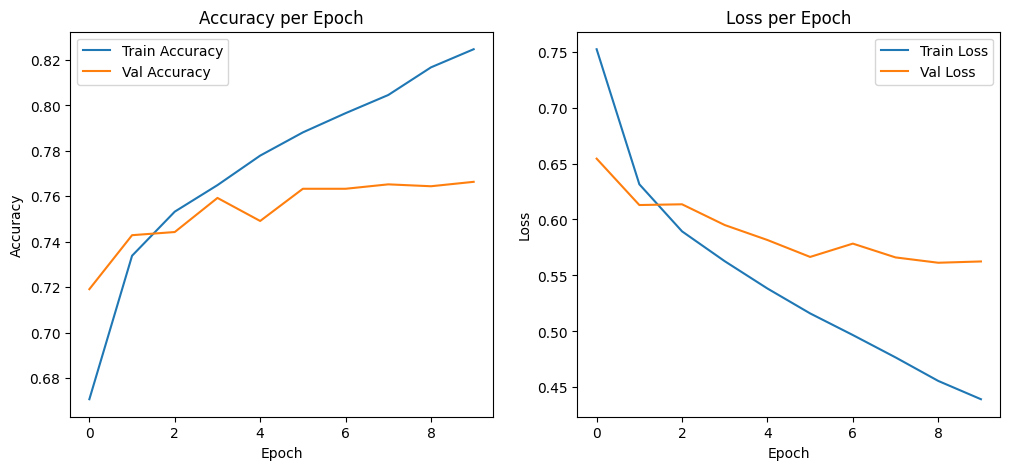

Best validation accuracy at epoch 10: 0.7664


In [70]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.show()

# Print the epoch with the best val accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best validation accuracy at epoch {best_epoch}: {history.history['val_accuracy'][best_epoch-1]:.4f}")


# Evaluation of model performance

In [71]:
final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Train Loss: {final_train_loss:.4f}")

final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")


Train Accuracy: 0.8247
Train Loss: 0.4394
Validation Accuracy: 0.7664
Validation Loss: 0.5625


In [ ]:
# Evaluate on test set for final performance
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test set accuracy: {test_accuracy:.4f}, loss: {test_loss:.4f}")

# Evaluate on train set for final performance
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Final Train set accuracy: {train_accuracy:.4f}, loss: {train_loss:.4f}")


Final Test set accuracy: 0.7658, loss: 0.5710
Final Train set accuracy: 0.8403, loss: 0.4153


# Training Data check Evaluation

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 91s 40ms/step
Train classification report:
               precision    recall  f1-score   support

    Negative       0.84      0.86      0.85     24000
     Neutral       0.85      0.77      0.81     24000
    Positive       0.83      0.90      0.87     24000

    accuracy                           0.84     72000
   macro avg       0.84      0.84      0.84     72000
weighted avg       0.84      0.84      0.84     72000

Train Accuracy: 0.8403333333333334


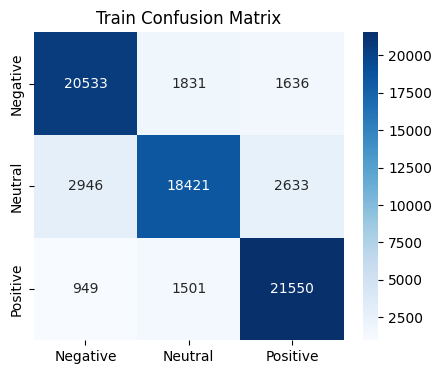

Train ROC-AUC (OvR): 0.95345362109375


In [73]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Training Metrics ---
y_train_pred = model.predict(X_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)
print("Train classification report:\n", classification_report(y_train, y_train_pred_labels, target_names=label_encoder.classes_))
train_acc = accuracy_score(y_train, y_train_pred_labels)
print("Train Accuracy:", train_acc)

# Confusion Matrix (Train)
cm_train = confusion_matrix(y_train, y_train_pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Train Confusion Matrix")
plt.show()

# AUC (Train)
y_train_bin = tf.keras.utils.to_categorical(y_train, num_classes=3)
train_auc = roc_auc_score(y_train_bin, y_train_pred, multi_class="ovr")
print("Train ROC-AUC (OvR):", train_auc)

## Checking ROC Curve

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 93s 41ms/step
563/563 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step


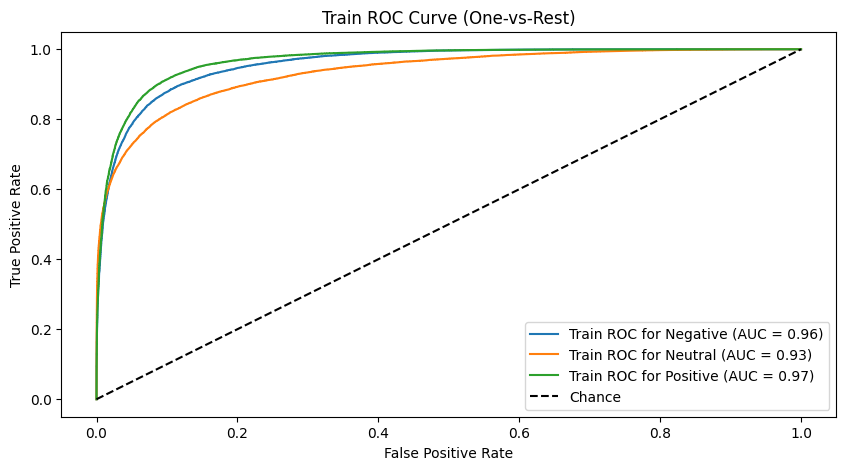

In [74]:
# Binarize labels for ROC computation (one-vs-rest)
n_classes = 3
y_train_bin = label_binarize(y_train, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Plot ROC curves for train
plt.figure(figsize=(10, 5))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Train ROC for {class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title('Train ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Test Data Check

563/563 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step
Test classification report:
               precision    recall  f1-score   support

    Negative       0.77      0.79      0.78      6000
     Neutral       0.75      0.67      0.71      6000
    Positive       0.78      0.84      0.81      6000

    accuracy                           0.77     18000
   macro avg       0.76      0.77      0.76     18000
weighted avg       0.76      0.77      0.76     18000

Test Accuracy: 0.7657777777777778


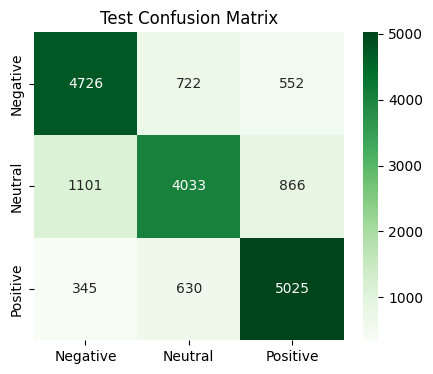

Test ROC-AUC (OvR): 0.9113502847222222


In [75]:
# --- Test Metrics ---
y_test_pred = model.predict(X_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)
print("Test classification report:\n", classification_report(y_test, y_test_pred_labels, target_names=label_encoder.classes_))
test_acc = accuracy_score(y_test, y_test_pred_labels)
print("Test Accuracy:", test_acc)

# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Test Confusion Matrix")
plt.show()

# AUC (Test)
y_test_bin = tf.keras.utils.to_categorical(y_test, num_classes=3)
test_auc = roc_auc_score(y_test_bin, y_test_pred, multi_class="ovr")
print("Test ROC-AUC (OvR):", test_auc)

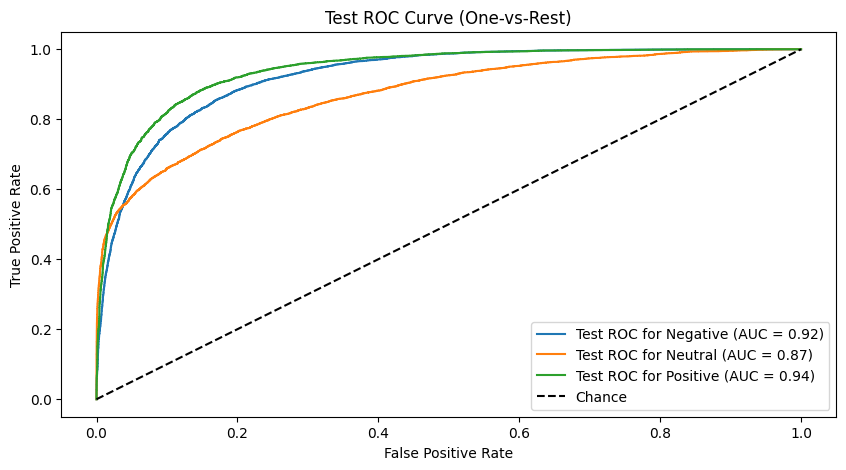

In [76]:
# Plot ROC curves for test
plt.figure(figsize=(10, 5))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Test ROC for {class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title('Test ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## LIME Interpretability 

In [77]:
from lime.lime_text import LimeTextExplainer

class_names = list(label_encoder.classes_)

def predict_proba(texts):
    # Tokenize and pad the input
    sequences = tokenizer.texts_to_sequences(texts)
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    # Get probabilities
    probs = model.predict(X)
    return probs


## Local Interpretability

In [94]:
explainer = LimeTextExplainer(class_names=class_names)

# Pick a tweet to explain
sample_idx = 100
tweet_text = corpus_df.iloc[sample_idx]['Cleaned_Text']

exp = explainer.explain_instance(
    tweet_text,          # The tweet text to explain
    predict_proba,       # Prediction function
    num_features=10,     # Number of words to highlight
    top_labels=1         # Explain the predicted label
)



157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step


In [95]:
# Predict the probability for this tweet
tweet_seq = tokenizer.texts_to_sequences([tweet_text])
tweet_seq_padded = pad_sequences(tweet_seq, maxlen=max_len, padding='post', truncating='post')
tweet_probs = model.predict(tweet_seq_padded)
pred_label_idx = np.argmax(tweet_probs)
pred_label = label_encoder.classes_[pred_label_idx]
confidence = tweet_probs[0][pred_label_idx]

print(f"Tweet: {tweet_text}")
print(f"Predicted class: {pred_label} (confidence: {confidence:.3f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Tweet: canadian freedom convoy raise 7 million on new crowdfunding platform
Predicted class: Positive (confidence: 0.979)


In [96]:
# the important words and their weights
print("Important words and their weights for this prediction:")
for word, weight in exp.as_list(label=exp.top_labels[0]):
    print(f"{word}: {weight:.3f}")

Important words and their weights for this prediction:
freedom: 0.630
convoy: 0.411
raise: 0.120
platform: -0.039
on: 0.034
million: 0.024
7: -0.011
canadian: 0.006
crowdfunding: 0.003
new: 0.002


In [98]:
# Pick n samples from each class in test set
n = 5
class_to_examples = {label: test_df[test_df['Sentiment_Merged'] == label].sample(n) for label in label_encoder.classes_}

# Store all important words
all_words = []

print("=== LIME explanations for multiple test tweets (one per class) ===\n")

for label, samples in class_to_examples.items():
    print(f"\n--- Class: {label} ---")
    for idx, row in samples.iterrows():
        tweet_text = row['Cleaned_Text']
        exp = explainer.explain_instance(
            tweet_text,
            predict_proba,
            num_features=6,
            top_labels=1
        )
        pred_label_idx = np.argmax(predict_proba([tweet_text]))
        pred_label = label_encoder.classes_[pred_label_idx]
        confidence = predict_proba([tweet_text])[0][pred_label_idx]
        print(f"\nTweet: {tweet_text}")
        print(f"Predicted: {pred_label} (conf: {confidence:.2f}) | True: {label}")
        for word, weight in exp.as_list(label=exp.top_labels[0]):
            print(f"  {word}: {weight:.3f}")
            all_words.append(word)

# Optional: Aggregate most important words across all explanations
from collections import Counter
top_global_words = Counter(all_words).most_common(10)
print("\n=== Most common contributing words across LIME explanations ===")
for word, count in top_global_words:
    print(f"{word}: {count} times")

=== LIME explanations for multiple test tweets (one per class) ===


--- Class: Negative ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Tweet: freedom convoy protester who block street could be arrest without a warrant ottawa police warn via
Predicted: Negative (conf: 0.83) | True: Negative
  freedom: -0.375
  arrest: 0.309
  block: 0.292
  warn: 0.161
  protester: 0.148
  convoy: -0.136
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Tweet: the countdown have begin and ottawa be prepare for the new round of protest schedule to begin on canada day cnmng news canada novax convoy freedomconvoy
Predicted: Negative (conf: 0.84) | True: Negative
  protest: 0.888
  convoy: -0.057
  prepare: -0.025
  day: -0.018
  countdown: 0.015
  schedule: 0.014
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━

# Saving Model 

In [81]:
import pickle

# Save Keras model
model.save("sentiment_transformer_model.h5")
model.save("sentiment_transformer_model.keras")



# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model, tokenizer, and label encoder saved successfully!")



Model, tokenizer, and label encoder saved successfully!


## GPT PROMPT

First Prompt: Give me a code for  Non-causal Transformer model using pretrained word2vec Skipgram  with position embeddings

Last Propmt: Give me existing pretrained model to use.